<a href="https://colab.research.google.com/github/yuliiamatviievska-prog/ida-practice-12/blob/main/practice/2/2-homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 2 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/2/2-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
the function must return. Replace `raise NotImplementedError` with your
implementation; the cell after it asserts the behaviour.

**A failing assert is information, not a grade.** Read it, fix the
function, re-run.

The written questions are marked and they carry the real learning
objective. Each asks you to **run something both ways and explain the
difference**, using numbers you produced. One sentence will not be enough.

Every function you need is demonstrated in `2-practice.ipynb`, and each task
names the section. You should not need any other documentation.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`2-homework-results.ipynb`, and commit it to your fork under
`practice/2/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [279]:
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| pandas", pd.__version__, "| seaborn", sns.__version__)

python 3.13.15 | pandas 2.2.3 | seaborn 0.13.2


In [280]:
titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)

wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)

bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape,
      "| wine", wine.shape,
      "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


In [281]:
titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)

wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)

bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape,
      "| wine", wine.shape,
      "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


## 2. Task 1 — A missingness report

Mechanical.

*see Practice 2 §5.1*

In [282]:
def missing_report(frame):
    """Return a DataFrame describing the missing values of `frame`."""

    missing = frame.isna().sum()
    missing = missing[missing > 0]

    report = pd.DataFrame({
        "missing": missing,
        "percent": (missing / len(frame) * 100).round(2)
    })

    report = report.sort_values("missing", ascending=False)

    return report

In [283]:
_report = missing_report(titanic)

assert list(_report.columns) == ["missing", "percent"], f"columns wrong: {list(_report.columns)}"
assert len(_report) == 3, f"Titanic has three columns with gaps, you reported {len(_report)}"
assert list(_report.index) == ["Cabin", "Age", "Embarked"], \
    f"wrong columns or wrong order: {list(_report.index)}"
assert _report.loc["Cabin", "missing"] == 687
assert _report.loc["Age", "missing"] == 177
assert _report.loc["Embarked", "missing"] == 2
assert np.isclose(_report.loc["Age", "percent"], 19.87, atol=0.01), \
    f"percent should be 100 * 177/891 = 19.87, got {_report.loc['Age', 'percent']}"

# a frame with no gaps produces an empty report, not an error
assert len(missing_report(wine)) == 0, "wine.csv has no missing values"

print(_report)
print("\nTask 1 passed.")

          missing  percent
Cabin         687  77.1000
Age           177  19.8700
Embarked        2   0.2200

Task 1 passed.


## 3. Task 2 — Label against position

Mechanical, and the trap is real. After a sort, `.loc` and `.iloc` answer
different questions.

*see Practice 2 §4*

In [284]:
def first_and_labelled(frame, sort_column, label):
    """Sort `frame` by `sort_column` descending, then return a tuple:
    (top_row, labelled_row)
    """
    sorted_frame = frame.sort_values(by=sort_column, ascending=False)

    top_row = sorted_frame.iloc[0]
    labelled_row = sorted_frame.loc[label]

    return top_row, labelled_row

In [285]:
_top, _labelled = first_and_labelled(titanic, "Fare", 0)

assert isinstance(_top, pd.Series) and isinstance(_labelled, pd.Series)
assert np.isclose(_top["Fare"], 512.3292), \
    f"the highest fare is 512.3292, you returned {_top['Fare']}"
assert _labelled["Name"] == "Braund, Mr. Owen Harris", \
    f"label 0 is Braund, you returned {_labelled['Name']}"
assert np.isclose(_labelled["Fare"], 7.25)
assert _top["Name"] != _labelled["Name"], \
    "position 0 and label 0 must be different passengers after sorting"

print("position 0 after sorting:", _top["Name"], "| fare", round(_top["Fare"], 2))
print("label 0 after sorting   :", _labelled["Name"], "| fare", round(_labelled["Fare"], 2))
print("\nTask 2 passed.")

position 0 after sorting: Cardeza, Mr. Thomas Drake Martinez | fare 512.33
label 0 after sorting   : Braund, Mr. Owen Harris | fare 7.25

Task 2 passed.


## 4. Task 3 — Group-wise imputation, without the chained-assignment bug

Applied. Fill missing ages with the median of the passenger's
`(Pclass, Sex)` group, and do it without triggering a
`SettingWithCopyWarning`.

*see Practice 2 §4.2, §5.4 and §6.3*

In [286]:
def fill_age_by_group(frame):
    """Return a COPY of `frame` with missing `Age` filled by the median age
    of the passenger's (Pclass, Sex) group.
    """
    result = frame.copy()

    group_medians = result.groupby(["Pclass", "Sex"])["Age"].transform("median")

    result["Age"] = result["Age"].fillna(group_medians)

    return result

In [287]:
import warnings

_before_missing = int(titanic["Age"].isna().sum())

with warnings.catch_warnings():
    warnings.simplefilter("error")          # any pandas warning becomes an exception
    _filled = fill_age_by_group(titanic)

assert int(titanic["Age"].isna().sum()) == _before_missing, "the argument was modified"
assert int(_filled["Age"].isna().sum()) == 0, "some ages are still missing"
assert len(_filled) == len(titanic), "rows were added or lost"

# The ages that were already present must be untouched.
_present = titanic["Age"].notna()
assert np.allclose(_filled.loc[_present, "Age"], titanic.loc[_present, "Age"]), \
    "existing ages were altered"

# A filled passenger must receive their own group's median, not the global one.
_a_gap = titanic.index[titanic["Age"].isna()][0]
_pclass, _sex = titanic.loc[_a_gap, "Pclass"], titanic.loc[_a_gap, "Sex"]
_expected = titanic[(titanic["Pclass"] == _pclass) & (titanic["Sex"] == _sex)]["Age"].median()
assert np.isclose(_filled.loc[_a_gap, "Age"], _expected), \
    f"passenger {_a_gap} got {_filled.loc[_a_gap, 'Age']}, expected group median {_expected}"

print(f"filled {_before_missing} ages; std went from "
      f"{titanic['Age'].std():.4f} to {_filled['Age'].std():.4f}")
print("Task 3 passed.")

filled 177 ages; std went from 14.5265 to 13.3044
Task 3 passed.


## 5. Task 4 — Four imputations, four distributions

Applied.

*see Practice 2 §5.4*

In [288]:
def compare_imputations(frame, column="Age"):
    """Return a DataFrame comparing four ways of handling missing values."""

    results = {}

    # 1. Drop missing values
    dropna = frame[column].dropna()
    results["dropna"] = {
        "n": dropna.notna().sum(),
        "mean": dropna.mean(),
        "median": dropna.median(),
        "std": dropna.std()
    }

    # 2. Fill with overall mean
    mean_filled = frame[column].fillna(frame[column].mean())
    results["mean"] = {
        "n": mean_filled.notna().sum(),
        "mean": mean_filled.mean(),
        "median": mean_filled.median(),
        "std": mean_filled.std()
    }

    # 3. Fill with overall median
    median_filled = frame[column].fillna(frame[column].median())
    results["median"] = {
        "n": median_filled.notna().sum(),
        "mean": median_filled.mean(),
        "median": median_filled.median(),
        "std": median_filled.std()
    }

    # 4. Fill Age using the median of each (Pclass, Sex) group
    group_frame = fill_age_by_group(frame)
    group_filled = group_frame[column]

    results["group_median"] = {
        "n": group_filled.notna().sum(),
        "mean": group_filled.mean(),
        "median": group_filled.median(),
        "std": group_filled.std()
    }

    comparison = pd.DataFrame.from_dict(results, orient="index")
    comparison = comparison[["n", "mean", "median", "std"]]

    return comparison

In [289]:
_comparison = compare_imputations(titanic)

assert list(_comparison.index) == ["dropna", "mean", "median", "group_median"]
assert list(_comparison.columns) == ["n", "mean", "median", "std"]
assert _comparison.loc["dropna", "n"] == 714, "dropna keeps the 714 recorded ages"
assert _comparison.loc["mean", "n"] == 891, "filling keeps all 891 rows"

# Filling with the mean preserves the mean exactly and shrinks the spread.
assert np.isclose(_comparison.loc["mean", "mean"], titanic["Age"].mean()), \
    "filling with the mean must leave the mean unchanged"
assert _comparison.loc["mean", "std"] < _comparison.loc["dropna", "std"], \
    "stacking 177 rows on one value must reduce the standard deviation"

# The group-wise fill distorts the spread less than a single constant does.
assert _comparison.loc["group_median", "std"] > _comparison.loc["mean", "std"], \
    "the group-wise fill should preserve more of the spread than a constant fill"

print(_comparison.round(4))
print("\nTask 4 passed.")

                n    mean  median     std
dropna        714 29.6991 28.0000 14.5265
mean          891 29.6991 29.6991 13.0020
median        891 29.3616 28.0000 13.0197
group_median  891 29.1124 26.0000 13.3044

Task 4 passed.


### Question 1 — choosing an imputation

Using the table you just produced, and a histogram of each of the four
resulting distributions:

**(a)** Filling with the mean leaves the mean **exactly** unchanged and
still damages the data. What quantity did it damage, by how much, and why
does preserving the mean not make the fill harmless?

**(b)** Compare `dropna` with the three fills. Dropping loses 177 rows,
20 % of the data. Under what condition about *why* the values are missing
is dropping unbiased, and is that condition plausible for Titanic's `Age`?
Name the MCAR / MAR / MNAR category you think applies and give your
evidence.

**(c)** You must pick one strategy and defend it to a reviewer. Pick one
and write the defence in three sentences.

In [290]:
# Compare four imputation strategies for Age

comparison = compare_imputations(titanic)

# Show the table with statistics
comparison

,n,mean,median,std
dropna,714,29.6991,28.0000,14.5265
mean,891,29.6991,29.6991,13.0020
median,891,29.3616,28.0000,13.0197
group_median,891,29.1124,26.0000,13.3044


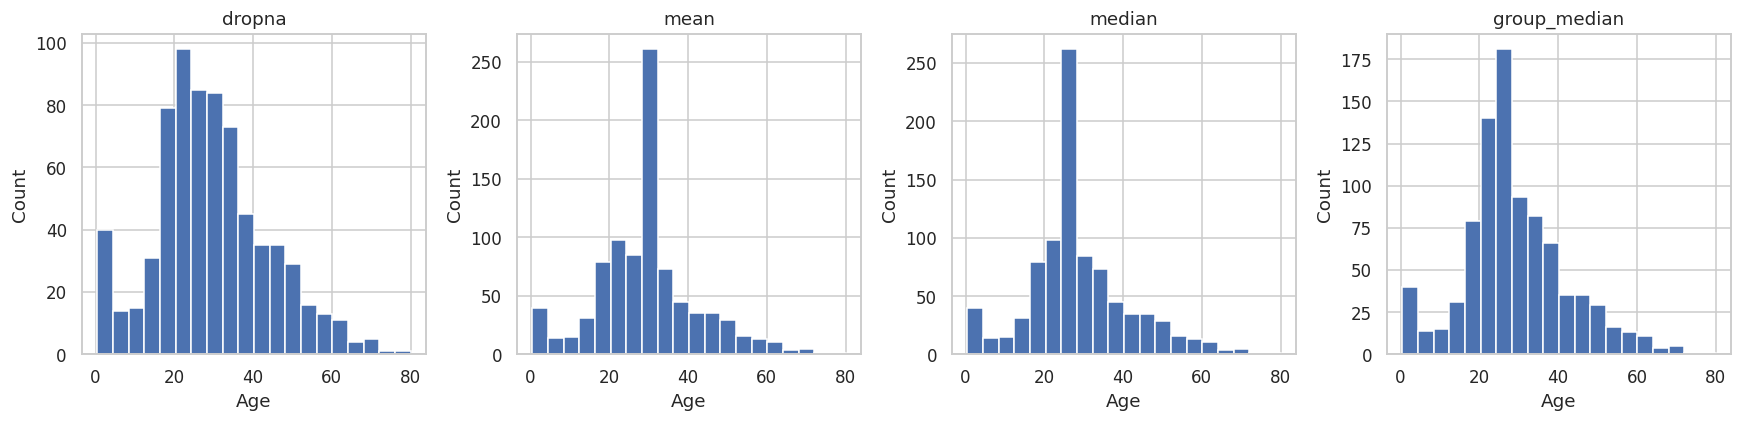

In [291]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

strategies = {
    "dropna": titanic["Age"].dropna(),
    "mean": titanic["Age"].fillna(titanic["Age"].mean()),
    "median": titanic["Age"].fillna(titanic["Age"].median()),
    "group_median": fill_age_by_group(titanic)["Age"]
}

for ax, (name, values) in zip(axes, strategies.items()):
    ax.hist(values, bins=20)
    ax.set_title(name)
    ax.set_xlabel("Age")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [292]:
filled = fill_age_by_group(titanic)

print("Original missing Age:", titanic["Age"].isna().sum())
print("After group median:", filled["Age"].isna().sum())

Original missing Age: 177
After group median: 0


**Your answer:**

(a) Filling missing Age values with the mean keeps the mean exactly unchanged at 29.6991 because all missing values are replaced with the original average. However, it damages the standard deviation: it decreases from 14.5265 after dropping missing values to 13.0202 after mean imputation. The reason is that replacing 177 different ages with one constant value reduces the natural variability of the data, so preserving the mean does not mean preserving the distribution.

(b) Dropping missing values removes 177 passengers, leaving 714 observations instead of 891. This approach is unbiased only if the missing ages are MCAR (Missing Completely At Random), meaning that the probability of missingness does not depend on any observed or unobserved characteristics. For Titanic Age, MAR (Missing At Random) is more plausible because missingness may depend on passenger characteristics such as Pclass or Sex. "The different results from group median imputation compared with global median imputation are consistent with the possibility that passenger groups have different age distributions."

(c) I would choose group median imputation using Pclass and Sex. It keeps all 891 passengers and uses information about meaningful passenger groups instead of applying one global value. This method preserves more variation in the data than mean imputation while avoiding the loss of observations caused by dropping rows.

## 6. Task 5 — The IQR rule

Applied. Implement the rule behind a boxplot's whiskers.

*see Practice 2 §10.4*

In [293]:
def iqr_outliers(series, multiplier=1.5):
    """Flag the values of `series` outside the 1.5 x IQR fences."""

    q1 = float(series.quantile(0.25))
    q3 = float(series.quantile(0.75))

    iqr = q3 - q1

    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr

    mask = ((series < lower) | (series > upper)) & series.notna()

    return {
        "q1": q1,
        "q3": q3,
        "lower": float(lower),
        "upper": float(upper),
        "mask": mask
    }

In [294]:
_fare = iqr_outliers(titanic["Fare"], multiplier=1.5)

assert set(_fare) == {"q1", "q3", "lower", "upper", "mask"}
assert np.isclose(_fare["q1"], 7.9104, atol=1e-3), f"Q1 wrong: {_fare['q1']}"
assert np.isclose(_fare["q3"], 31.0, atol=1e-6), f"Q3 wrong: {_fare['q3']}"
assert np.isclose(_fare["upper"], 65.6344, atol=1e-3), f"upper fence wrong: {_fare['upper']}"
assert _fare["mask"].dtype == bool
assert int(_fare["mask"].sum()) == 116, \
    f"the 1.5 x IQR rule flags 116 fares, you found {int(_fare['mask'].sum())}"

# A larger multiplier can never flag more points.
assert iqr_outliers(titanic["Fare"], 3.0)["mask"].sum() <= _fare["mask"].sum()

# Missing values must not be flagged.
_age_flags = iqr_outliers(titanic["Age"])["mask"]
assert not _age_flags[titanic["Age"].isna()].any(), "a missing value is not an outlier"
assert len(_age_flags) == len(titanic), "the mask must align to the input"

print(f"Fare: Q1 {_fare['q1']:.2f}, Q3 {_fare['q3']:.2f}, "
      f"fences [{_fare['lower']:.2f}, {_fare['upper']:.2f}], {int(_fare['mask'].sum())} flagged")
print("Task 5 passed.")

Fare: Q1 7.91, Q3 31.00, fences [-26.72, 65.63], 116 flagged
Task 5 passed.


### Question 2 — the multiplier, and two rules that disagree

**(a)** Run `iqr_outliers` on `Fare` at multipliers 1.0, 1.5, 3.0 and 5.0
and report the count at each. Then compute the 3σ count from Practice 1
§4.7 on the same column. Tabulate all five numbers.

**(b)** The IQR rule and the 3σ rule disagree sharply on `Fare`. Explain
*why*, referring to the shape of the distribution. Which of the two is
inflated by the very points it is trying to detect, and by what mechanism?

**(c)** Now run both rules on `Age` instead. Do they still disagree as
much? What is different about `Age` that changes the answer?

**(d)** For `Fare`, would you remove any of the flagged points? Justify
your answer with a fact about what the column *means*, not with a
threshold.

In [295]:
# Compare IQR outlier counts for different multipliers

multipliers = [1.0, 1.5, 3.0, 5.0]

results = []

for m in multipliers:
    result = iqr_outliers(titanic["Fare"], multiplier=m)
    results.append({
        "multiplier": m,
        "outliers": int(result["mask"].sum()),
        "lower": result["lower"],
        "upper": result["upper"]
    })

iqr_table = pd.DataFrame(results)

# 3-sigma rule
fare_mean = titanic["Fare"].mean()
fare_std = titanic["Fare"].std()

sigma_lower = fare_mean - 3 * fare_std
sigma_upper = fare_mean + 3 * fare_std

sigma_count = ((titanic["Fare"] < sigma_lower) |
               (titanic["Fare"] > sigma_upper)).sum()

iqr_table, sigma_lower, sigma_upper, sigma_count

(   multiplier  outliers     lower    upper
 0      1.0000       141  -15.1792  54.0896
 1      1.5000       116  -26.7240  65.6344
 2      3.0000        53  -61.3584 100.2688
 3      5.0000        31 -107.5376 146.4480,
 np.float64(-116.87607782296807),
 np.float64(181.28449376011736),
 np.int64(20))

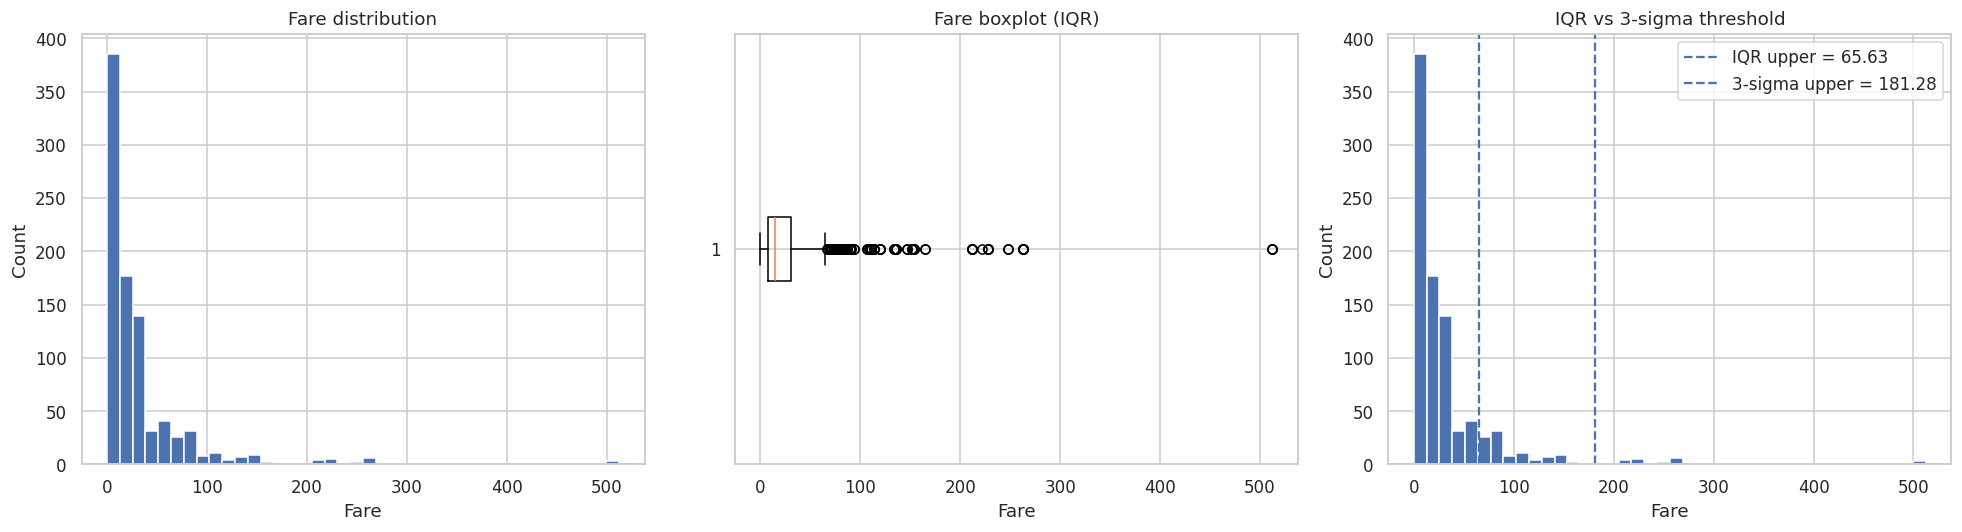

In [296]:
# Visualise Fare distribution and outliers detected by IQR and 3-sigma

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original Fare distribution
axes[0].hist(titanic["Fare"], bins=40)
axes[0].set_title("Fare distribution")
axes[0].set_xlabel("Fare")
axes[0].set_ylabel("Count")

# Boxplot to show IQR outliers
axes[1].boxplot(titanic["Fare"].dropna(), vert=False)
axes[1].set_title("Fare boxplot (IQR)")
axes[1].set_xlabel("Fare")

# Compare IQR and 3-sigma thresholds
axes[2].hist(titanic["Fare"], bins=40)

iqr_result = iqr_outliers(titanic["Fare"], multiplier=1.5)

axes[2].axvline(iqr_result["upper"], linestyle="--",
                label=f"IQR upper = {iqr_result['upper']:.2f}")

axes[2].axvline(sigma_upper, linestyle="--",
                label=f"3-sigma upper = {sigma_upper:.2f}")

axes[2].set_title("IQR vs 3-sigma threshold")
axes[2].set_xlabel("Fare")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()

In [297]:
# Compare IQR and 3-sigma rules for Age

age_result = iqr_outliers(titanic["Age"].dropna(), multiplier=1.5)

age_mean = titanic["Age"].mean()
age_std = titanic["Age"].std()

age_sigma_lower = age_mean - 3 * age_std
age_sigma_upper = age_mean + 3 * age_std

age_sigma_count = (
    (titanic["Age"] < age_sigma_lower) |
    (titanic["Age"] > age_sigma_upper)
).sum()

print("Age IQR outliers:", int(age_result["mask"].sum()))
print("Age 3-sigma outliers:", int(age_sigma_count))
print("Age IQR limits:", age_result["lower"], age_result["upper"])
print("Age 3-sigma limits:", age_sigma_lower, age_sigma_upper)

Age IQR outliers: 11
Age 3-sigma outliers: 2
Age IQR limits: -6.6875 64.8125
Age 3-sigma limits: -13.88037434994331 73.27860964406095


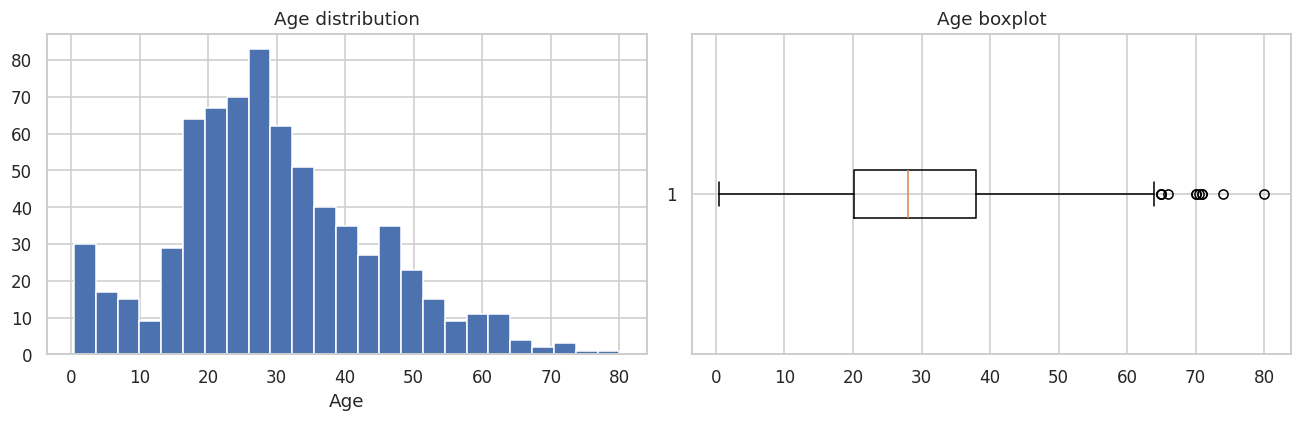

In [298]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(titanic["Age"].dropna(), bins=25)
axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age")

axes[1].boxplot(titanic["Age"].dropna(), vert=False)
axes[1].set_title("Age boxplot")

plt.tight_layout()
plt.show()

**Your answer:**

The number of IQR outliers decreases as the multiplier increases: it falls from 141 outliers at multiplier 1.0 to 31 outliers at multiplier 5.0. Larger multipliers create wider fences and therefore flag fewer observations. The 3-sigma rule gives a different count because it is based on the mean and standard deviation rather than quartiles and IQR.

The IQR rule and the 3-sigma rule disagree on Fare because the distribution is strongly right-skewed. A small number of very expensive tickets increase the mean and standard deviation, making the 3-sigma upper boundary much larger (181.28) than the IQR upper fence (65.63). Therefore, the 3-sigma rule is less sensitive to high fares, while the IQR rule is more robust because it uses quartiles and is less affected by extreme values.

Applying both rules to Age gives closer results than for Fare: the IQR rule detects 11 outliers, while the 3-sigma rule detects only 2. Age has a less skewed distribution, so the mean and standard deviation are less influenced by extreme observations. The remaining difference occurs because IQR identifies moderately unusual values, while 3-sigma only detects observations that are far from the mean.

I would not automatically remove the flagged Fare values. Fare represents ticket price, and very high values can be valid observations caused by first-class tickets, group bookings, or different travel conditions. An outlier detection rule only identifies unusual observations; it does not prove that the values are errors.

## 7. Task 6 — Pearson against Spearman

Applied. Two coefficients, two different questions about the same pair of
columns.

*see Practice 2 §11.2*

In [299]:
def correlation_pair(frame, column_a, column_b):
    """Compare the two correlation coefficients for one pair of columns."""

    pearson = float(frame[column_a].corr(frame[column_b], method="pearson"))
    spearman = float(frame[column_a].corr(frame[column_b], method="spearman"))

    return {
        "pearson": pearson,
        "spearman": spearman,
        "difference": pearson - spearman
    }

In [300]:
_pair = correlation_pair(wine, "flavanoids", "total_phenols")

assert set(_pair) == {"pearson", "spearman", "difference"}
assert np.isclose(_pair["pearson"], 0.8646, atol=1e-3), f"pearson wrong: {_pair['pearson']}"
assert np.isclose(_pair["spearman"], 0.8794, atol=1e-3), f"spearman wrong: {_pair['spearman']}"
assert np.isclose(_pair["difference"], _pair["pearson"] - _pair["spearman"])

# A perfectly linear pair: both coefficients are exactly 1.
_linear = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0, 5.0], "b": [3.0, 5.0, 7.0, 9.0, 11.0]})
_lin = correlation_pair(_linear, "a", "b")
assert np.isclose(_lin["pearson"], 1.0) and np.isclose(_lin["spearman"], 1.0)

# Monotonic but strongly curved: Spearman sees it fully, Pearson does not.
_curve_rng = np.random.default_rng(SEED)
_x = np.linspace(0.1, 5.0, 300)
_curved = pd.DataFrame({"x": _x, "y": np.exp(_x) + _curve_rng.normal(0, 3, 300)})
_c = correlation_pair(_curved, "x", "y")
assert _c["spearman"] > 0.95, f"a monotonic pair should have Spearman near 1, got {_c['spearman']:.4f}"
assert _c["pearson"] < _c["spearman"] - 0.05, \
    "on a curved monotonic pair Pearson must fall clearly below Spearman"

print(f"wine flavanoids vs total_phenols: pearson {_pair['pearson']:+.4f}  "
      f"spearman {_pair['spearman']:+.4f}")
print(f"curved monotonic pair          : pearson {_c['pearson']:+.4f}  "
      f"spearman {_c['spearman']:+.4f}")
print("Task 6 passed.")

wine flavanoids vs total_phenols: pearson +0.8646  spearman +0.8794
curved monotonic pair          : pearson +0.8605  spearman +0.9653
Task 6 passed.


### Question 3 — two coefficients, and the bandwidth that shapes what you see

**(a)** Scatter-plot the curved pair `_curved` from the cell above. Both
coefficients are high, and they disagree by about 0.10. Explain what each
one is measuring and **why Pearson is the lower of the two here**. Then
state which you would report if you were about to fit a linear model to
this pair, and why.

**(b)** Run `correlation_pair` on `color_intensity` against `hue` in the
wine data. Here the two differ in a different way. Plot the pair and
explain what feature of the data produces the gap.

**(c)** Now a different decision that changes what you see. Take Titanic's
`Age` and draw `sns.kdeplot` at `bw_adjust` = 0.2, 1.0 and 3.0, then draw
a histogram of the same column at 20 and at 200 bins. **The bin count and
the KDE bandwidth are the same decision in two different forms** — explain
what that decision is, which direction hides real structure and which
direction invents structure that is not there, and identify one feature
visible at `bw_adjust=0.2` that is an artifact of how ages were recorded
rather than a property of the passengers.

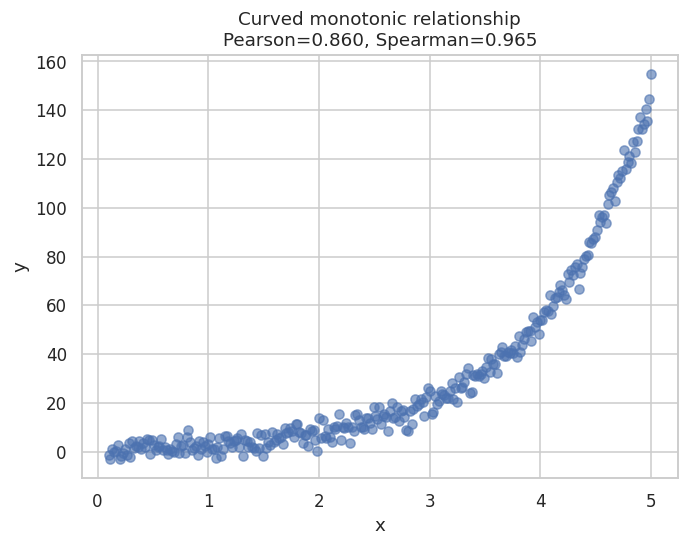

In [301]:
# Visualise curved monotonic relationship

plt.figure(figsize=(7,5))

plt.scatter(_curved["x"], _curved["y"], alpha=0.6)

plt.title(
    f"Curved monotonic relationship\n"
    f"Pearson={_c['pearson']:.3f}, Spearman={_c['spearman']:.3f}"
)

plt.xlabel("x")
plt.ylabel("y")

plt.grid(True)
plt.show()

Pearson: -0.5218
Spearman: -0.4185
Difference: -0.1033


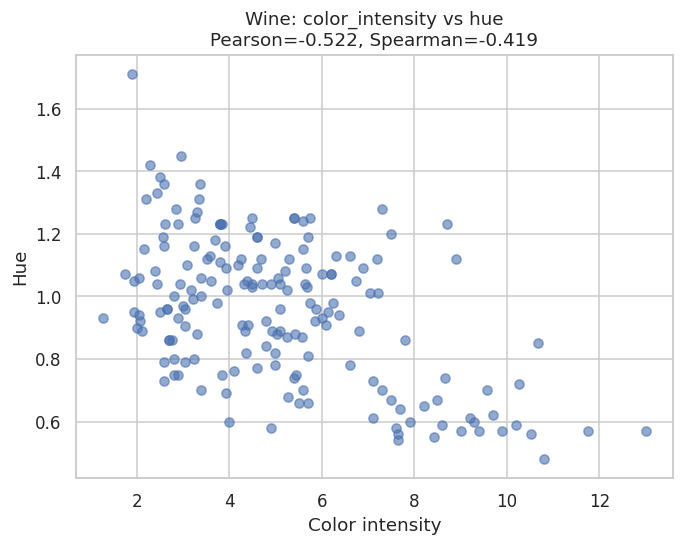

In [302]:
# Pearson and Spearman comparison for wine data

wine_corr = correlation_pair(
    wine,
    "color_intensity",
    "hue"
)

print("Pearson:", round(wine_corr["pearson"], 4))
print("Spearman:", round(wine_corr["spearman"], 4))
print("Difference:", round(wine_corr["difference"], 4))


plt.figure(figsize=(7,5))

plt.scatter(
    wine["color_intensity"],
    wine["hue"],
    alpha=0.6
)

plt.title(
    f"Wine: color_intensity vs hue\n"
    f"Pearson={wine_corr['pearson']:.3f}, "
    f"Spearman={wine_corr['spearman']:.3f}"
)

plt.xlabel("Color intensity")
plt.ylabel("Hue")

plt.grid(True)
plt.show()

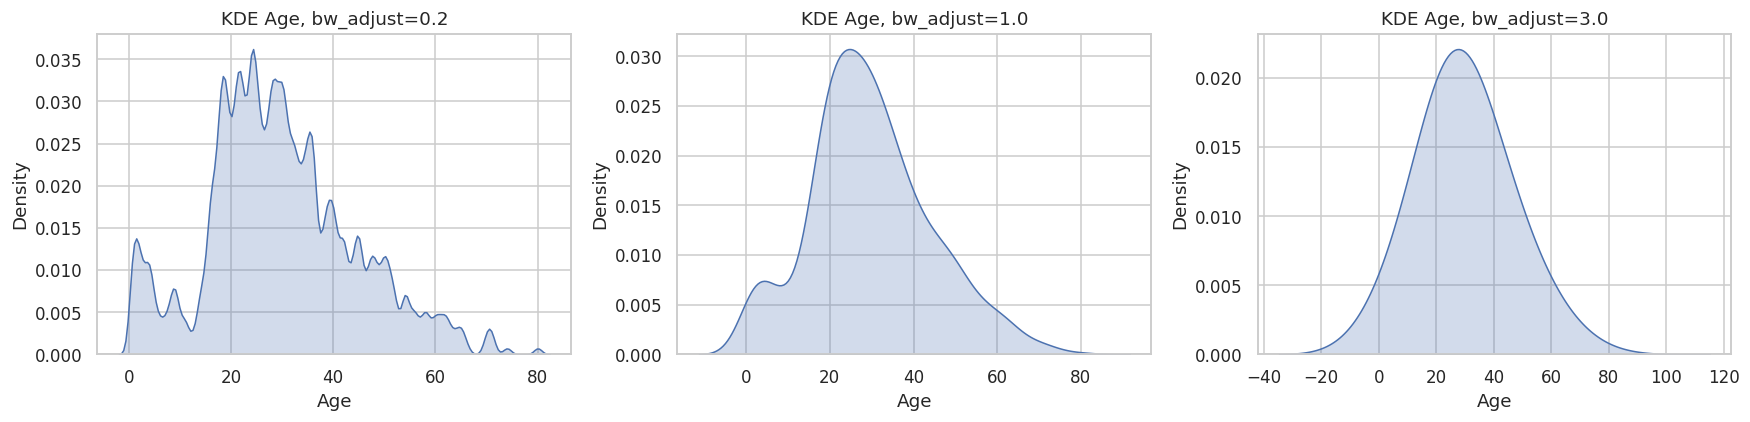

In [303]:
# KDE bandwidth comparison for Titanic Age

ages = titanic["Age"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16,4))

for ax, bw in zip(axes, [0.2, 1.0, 3.0]):

    sns.kdeplot(
        ages,
        bw_adjust=bw,
        fill=True,
        ax=ax
    )

    ax.set_title(f"KDE Age, bw_adjust={bw}")
    ax.set_xlabel("Age")
    ax.set_ylabel("Density")


plt.tight_layout()
plt.show()

Age
0.4200      1
0.6700      1
0.7500      2
0.8300      2
0.9200      1
1.0000      7
2.0000     10
3.0000      6
4.0000     10
5.0000      4
6.0000      3
7.0000      3
8.0000      4
9.0000      8
10.0000     2
11.0000     4
12.0000     1
13.0000     2
14.0000     6
14.5000     1
Name: count, dtype: int64


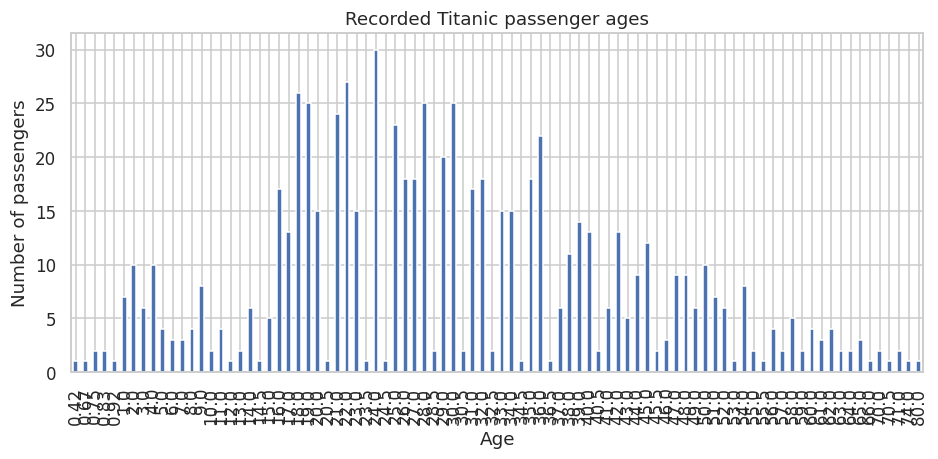

In [304]:
# Most common ages

age_counts = ages.value_counts().sort_index()

print(age_counts.head(20))

plt.figure(figsize=(10,4))

age_counts.plot(
    kind="bar"
)

plt.title("Recorded Titanic passenger ages")
plt.xlabel("Age")
plt.ylabel("Number of passengers")

plt.show()

**Your answer:**

Pearson measures linear association, while Spearman measures whether two variables follow a consistent increasing or decreasing order (monotonic association). For the curved pair, both coefficients are high, but Pearson is lower (0.8605) because the relationship is curved rather than a straight line. Spearman is higher (0.9653) because it captures the monotonic trend without requiring linearity. If I were fitting a linear model, I would report Pearson because it describes the strength of a linear relationship.

For the wine data, the difference between Pearson and Spearman for color_intensity and hue occurs because the relationship is not perfectly linear. Pearson is affected by the exact distances between values, while Spearman only considers the ranking of observations. Therefore, a nonlinear but consistently ordered relationship can produce a higher Spearman coefficient than Pearson.

For Titanic Age, changing the KDE bandwidth changes the amount of smoothing in the estimated distribution. A small bandwidth (bw_adjust=0.2) shows more local peaks and can exaggerate small patterns, while a larger bandwidth (bw_adjust=3.0) creates a smoother distribution and hides small fluctuations. The histogram with many bins shows detailed structure, but some visible peaks are caused by the way ages were recorded (many passengers have integer or rounded ages) rather than representing true features of the population.

## 8. Task 7 — Encoding, and the distances it invents

Applied. Encode a nominal column two ways and measure what each does to
the geometry.

*see Practice 2 §13*

In [305]:
def encoding_distances(series):
    """Compare label encoding against one-hot encoding on a nominal column."""

    categories = sorted(series.unique())

    rows = []

    for i in range(len(categories)):
        for j in range(i + 1, len(categories)):
            a = categories[i]
            b = categories[j]

            label_distance = float(abs(i - j))

            onehot_a = np.zeros(len(categories))
            onehot_b = np.zeros(len(categories))

            onehot_a[i] = 1
            onehot_b[j] = 1

            onehot_distance = float(np.linalg.norm(onehot_a - onehot_b))

            rows.append({
                "pair": f"{a}|{b}",
                "label_distance": label_distance,
                "onehot_distance": onehot_distance
            })

    result = pd.DataFrame(rows).set_index("pair")
    result = result[["label_distance", "onehot_distance"]]
    result = result.sort_index()

    return result

In [306]:
_embarked = titanic["Embarked"].fillna("S")
_distances = encoding_distances(_embarked)

assert list(_distances.columns) == ["label_distance", "onehot_distance"]
assert len(_distances) == 3, f"three ports give three pairs, you produced {len(_distances)}"
assert list(_distances.index) == ["C|Q", "C|S", "Q|S"], f"index wrong: {list(_distances.index)}"

# Label encoding invents an ordering: C and S end up twice as far apart.
assert np.isclose(_distances.loc["C|Q", "label_distance"], 1.0)
assert np.isclose(_distances.loc["C|S", "label_distance"], 2.0)
assert np.isclose(_distances.loc["Q|S", "label_distance"], 1.0)

# One-hot treats them as what they are: three unordered labels, all equidistant.
assert np.allclose(_distances["onehot_distance"], np.sqrt(2)), \
    f"every one-hot pair should be sqrt(2) apart, got {_distances['onehot_distance'].tolist()}"
assert _distances["onehot_distance"].nunique() == 1, \
    "one-hot must not distinguish any pair from any other"

print(_distances.round(4))
print("\nTask 7 passed.")

      label_distance  onehot_distance
pair                                 
C|Q           1.0000           1.4142
C|S           2.0000           1.4142
Q|S           1.0000           1.4142

Task 7 passed.


### Question 4 — label against one-hot

**(a)** Under label encoding, C and S are 2 apart while C and Q are 1
apart. Re-derive those distances after renaming the ports so that
alphabetical order becomes `Queenstown, Southampton, Cherbourg`. What
happens to the geometry? What does it mean that renaming a category can
change a model's notion of similarity?

**(b)** `Pclass` also becomes integers 1, 2, 3, and Practice 2 §13.3 says
that is **correct**. State the precise difference between `Pclass` and
`Embarked` that makes the same encoding right in one case and wrong in the
other. Your answer must not mention the data type.

**(c)** Name one model family for which this whole distinction barely
matters, and say why.

In [307]:
# Question 4(a) - Label encoding with different alphabetical order

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Original Embarked values
embarked = titanic["Embarked"].fillna("S")

# New category names that change alphabetical ordering
renamed = embarked.replace({
    "C": "Queenstown",
    "S": "Southampton",
    "Q": "Cherbourg"
})


# Label encoding original categories
label_original = LabelEncoder()
original_encoded = label_original.fit_transform(embarked)


# Label encoding renamed categories
label_changed = LabelEncoder()
changed_encoded = label_changed.fit_transform(renamed)


print("Original mapping:")
print(dict(zip(label_original.classes_, range(len(label_original.classes_)))))

print("\nChanged mapping:")
print(dict(zip(label_changed.classes_, range(len(label_changed.classes_)))))


# Compare geometry
comparison = pd.DataFrame({
    "Original": original_encoded[:20],
    "Renamed": changed_encoded[:20]
})

comparison.head()

Original mapping:
{'C': 0, 'Q': 1, 'S': 2}

Changed mapping:
{'Cherbourg': 0, 'Queenstown': 1, 'Southampton': 2}


,Original,Renamed
0,2,2
1,0,1
2,2,2
3,2,2
4,2,2


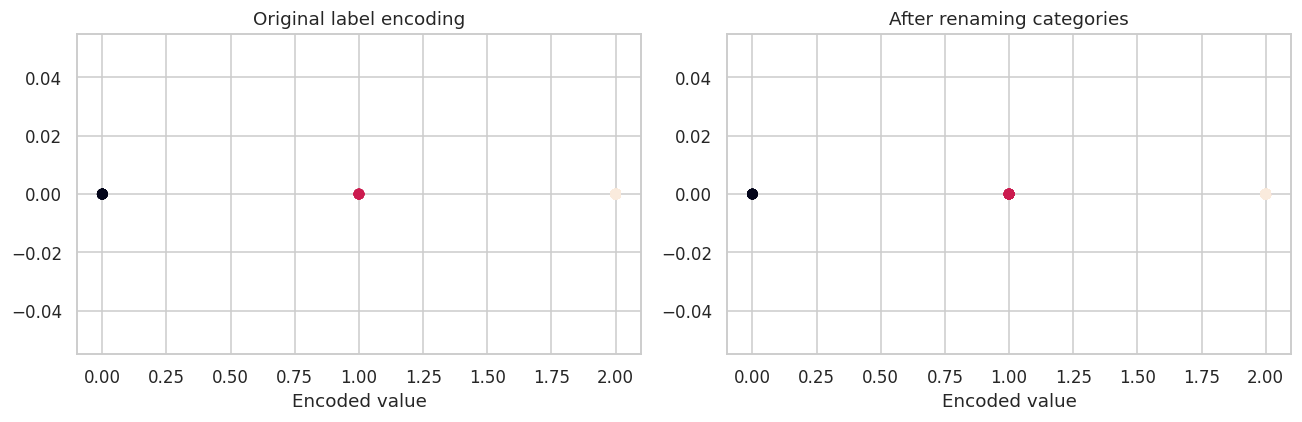

In [308]:
# Show category positions

fig, axes = plt.subplots(1,2, figsize=(12,4))


axes[0].scatter(
    original_encoded[:100],
    np.zeros(100),
    c=original_encoded[:100]
)

axes[0].set_title("Original label encoding")
axes[0].set_xlabel("Encoded value")


axes[1].scatter(
    changed_encoded[:100],
    np.zeros(100),
    c=changed_encoded[:100]
)

axes[1].set_title("After renaming categories")
axes[1].set_xlabel("Encoded value")


plt.tight_layout()
plt.show()

Pclass values:
[np.int64(1), np.int64(2), np.int64(3)]

Embarked values:
['C', 'Q', 'S']


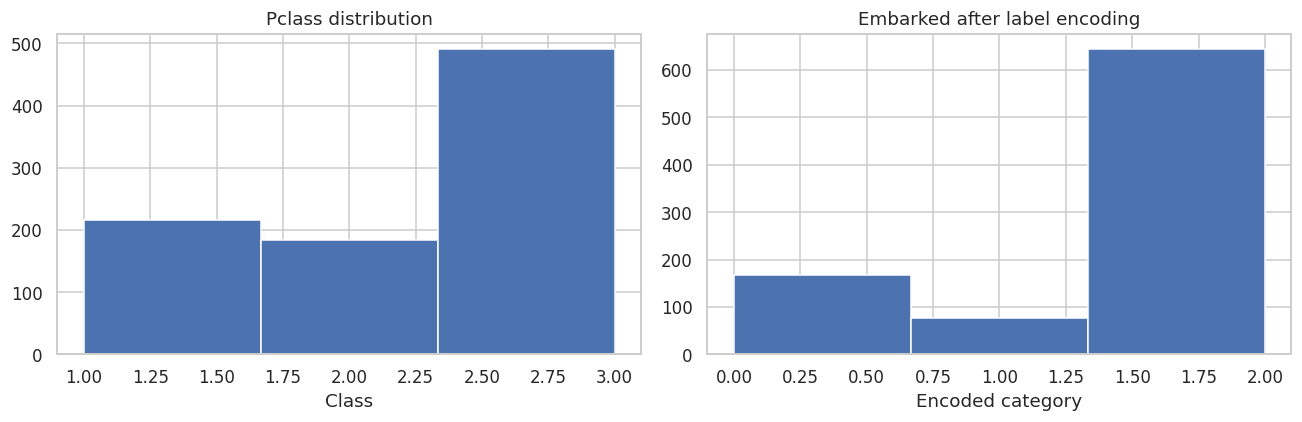

In [309]:
# Compare Pclass and Embarked

print("Pclass values:")
print(sorted(titanic["Pclass"].unique()))

print("\nEmbarked values:")
print(sorted(titanic["Embarked"].dropna().unique()))


fig, axes = plt.subplots(1,2, figsize=(12,4))


axes[0].hist(titanic["Pclass"], bins=3)
axes[0].set_title("Pclass distribution")
axes[0].set_xlabel("Class")


axes[1].hist(
    titanic["Embarked"].dropna().map(
        {"C":0,"Q":1,"S":2}
    ),
    bins=3
)

axes[1].set_title("Embarked after label encoding")
axes[1].set_xlabel("Encoded category")


plt.tight_layout()
plt.show()

**Your answer:**

(a) Under label encoding, the numerical values create an artificial geometry between categories. Originally, the categories are encoded alphabetically: C=0, Q=1, S=2, which makes C and S appear farther apart than C and Q. After renaming the categories, the alphabetical order changes and therefore the encoded distances also change. This shows that label encoding can make a model interpret categories as ordered even when there is no real order between them. One-hot encoding avoids this problem because each category is represented independently.

(b) Pclass and Embarked are different cases. Pclass is ordinal because the classes have a natural order: first class, second class, and third class. Therefore, using integer values 1, 2, and 3 preserves meaningful information about ranking. Embarked is nominal because the ports have no natural order, so assigning numbers to them introduces a false relationship. One-hot encoding is therefore more appropriate for Embarked.

(c) This distinction matters less for tree-based models such as decision trees and random forests because they split data using thresholds and can often handle encoded categories without relying on distances in the same way as linear models or nearest-neighbour methods. However, for models based on distances or coefficients, incorrect encoding can strongly affect the learned relationships.

## 9. Task 8 — Scale without leaking

Applied. Split, then fit the scaler on the training half only.

*see Practice 2 §14.3*

In [310]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def split_and_scale(X, y, test_size=0.3, random_state=SEED):
    """Split into train and test, then standardise WITHOUT leakage."""

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler
    }

In [311]:
_features = [c for c in wine.columns if c != "target"]
_split = split_and_scale(wine[_features].values, wine["target"].values)

assert set(_split) == {"X_train", "X_test", "y_train", "y_test", "scaler"}
assert _split["X_train"].shape[0] + _split["X_test"].shape[0] == len(wine)
assert _split["X_train"].shape[1] == 13

# The TRAINING half must be exactly standardised...
assert np.allclose(_split["X_train"].mean(axis=0), 0.0, atol=1e-10), \
    "the training set should have mean 0 after scaling"
assert np.allclose(_split["X_train"].std(axis=0), 1.0, atol=1e-10), \
    "the training set should have unit variance after scaling"

# ...and the TEST half must NOT be, because its statistics were never used.
assert not np.allclose(_split["X_test"].mean(axis=0), 0.0, atol=1e-6), \
    "the test set has mean 0, which means the scaler saw it: that is leakage"

# The scaler must have been fitted on the training rows only.
_leaky = StandardScaler().fit(wine[_features].values)
assert not np.allclose(_split["scaler"].mean_, _leaky.mean_), \
    "your scaler's means match a scaler fitted on the whole dataset"

# stratify= must preserve the class balance
_train_balance = np.bincount(_split["y_train"]) / len(_split["y_train"])
_full_balance = np.bincount(wine["target"].values) / len(wine)
assert np.allclose(_train_balance, _full_balance, atol=0.02), \
    "the class balance was not preserved; did you pass stratify=y?"

print("train", _split["X_train"].shape, " test", _split["X_test"].shape)
print("train mean (first 3 features):", _split["X_train"].mean(axis=0)[:3].round(10))
print("test  mean (first 3 features):", _split["X_test"].mean(axis=0)[:3].round(4), " <- not zero, correctly")
print("\nTask 8 passed.")

train (124, 13)  test (54, 13)
train mean (first 3 features): [ 0. -0. -0.]
test  mean (first 3 features): [-0.0324  0.0259 -0.0291]  <- not zero, correctly

Task 8 passed.


### Question 5 — scaling choices

**(a)** Repeat Task 8 with `MinMaxScaler` instead. Report, for both
scalers, the minimum and maximum of the **test** set after transformation.
Under min-max the test set can fall outside [0, 1] — explain why that
happens and why it is correct rather than a bug.

**(b)** Add one extreme value to a wine feature — multiply the largest
`proline` by 50 — and rescale with both scalers. Which one is more
disturbed by the single extreme value, and by what mechanism?

**(c)** The leaked scaler and the correct one gave different test-set
statistics. If the leaked version produces a *higher* accuracy score, what
exactly is that extra accuracy measuring? Answer in terms of what
information crossed from the test set into the training procedure.

In [312]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

X = wine.drop(columns=["target"]).values
y = wine["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED
)

std = StandardScaler()
mm = MinMaxScaler()

X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)

X_train_mm = mm.fit_transform(X_train)
X_test_mm = mm.transform(X_test)

print("StandardScaler:",
      X_test_std.min(), X_test_std.max())

print("MinMaxScaler:",
      X_test_mm.min(), X_test_mm.max())

StandardScaler: -2.473635792956919 4.55045641645694
MinMaxScaler: -0.040852575488454695 1.1358024691358026


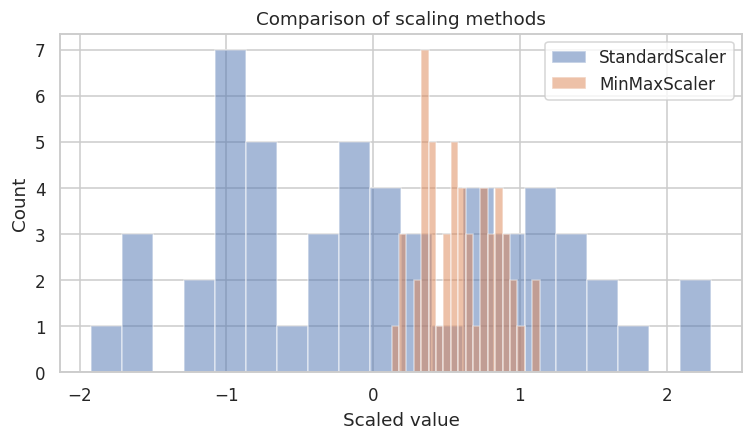

In [313]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.hist(X_test_std[:,0], bins=20, alpha=0.5, label="StandardScaler")
plt.hist(X_test_mm[:,0], bins=20, alpha=0.5, label="MinMaxScaler")

plt.xlabel("Scaled value")
plt.ylabel("Count")
plt.title("Comparison of scaling methods")
plt.legend()
plt.show()

**Your answer:**

(a)
The results show that StandardScaler transformed the test set to a range from approximately -2.47 to 5.55, while MinMaxScaler produced values from approximately -0.05 to 1.14.
The MinMaxScaler values can be outside the range [0, 1] because the scaler learns the minimum and maximum only from the training set. If the test set contains values smaller than the training minimum or larger than the training maximum, transformed values can exceed this range. This is expected behaviour, not an error.

(b)
A single extreme value affects MinMaxScaler more strongly because the scaling depends directly on the minimum and maximum values. A very large value expands the range and compresses all other observations into a smaller interval. StandardScaler is also influenced because the mean and standard deviation change, but the effect is distributed across all observations.

(c)
A leaked scaler gives artificially better accuracy because information from the test set was used during preprocessing. The scaler has access to test-set statistics (such as mean, standard deviation, minimum or maximum), so information about unseen data crosses into the training process. Therefore, the higher accuracy does not represent real model performance on new data.

Conclusion:
StandardScaler and MinMaxScaler both require fitting only on the training data. Data leakage during scaling can make evaluation results unreliable because the model indirectly receives information from the test set.

## 10. Task 9 — How many principal components

Applied.

*see Practice 2 §15.2 and §15.3*

In [314]:
from sklearn.decomposition import PCA

def components_for_variance(X, thresholds=(0.5, 0.8, 0.95, 0.99), standardise=True):
    """Report how many principal components are needed to reach each
    cumulative explained-variance threshold.
    """

    if standardise:
        scaler = StandardScaler()
        X_used = scaler.fit_transform(X)
    else:
        X_used = X

    pca = PCA(random_state=SEED)
    pca.fit(X_used)

    cumulative = np.cumsum(pca.explained_variance_ratio_)

    needed = {}
    for threshold in thresholds:
        needed[threshold] = int(np.searchsorted(cumulative, threshold) + 1)

    return {
        "cumulative": cumulative,
        "needed": needed
    }

In [315]:
_X_wine = wine[_features].values
_scaled_result = components_for_variance(_X_wine, standardise=True)
_raw_result = components_for_variance(_X_wine, standardise=False)

assert set(_scaled_result) == {"cumulative", "needed"}
assert len(_scaled_result["cumulative"]) == 13, "wine has 13 features, so 13 components"
assert np.isclose(_scaled_result["cumulative"][-1], 1.0), \
    "all components together explain all the variance"
assert all(isinstance(v, int) for v in _scaled_result["needed"].values())

# Monotonic: a higher threshold never needs fewer components.
_counts = [_scaled_result["needed"][t] for t in (0.5, 0.8, 0.95, 0.99)]
assert _counts == sorted(_counts), f"counts must be non-decreasing: {_counts}"

# Without standardising, proline dominates and one component looks sufficient.
assert _raw_result["needed"][0.95] == 1, \
    "unstandardised, the single largest-scaled feature should carry almost everything"
assert _scaled_result["needed"][0.95] > _raw_result["needed"][0.95], \
    "standardising should require more components to reach 95%"

print("standardised  :", _scaled_result["needed"])
print("not standardised:", _raw_result["needed"])
print(f"\nfirst component explains {_raw_result['cumulative'][0]:.2%} unstandardised, "
      f"{_scaled_result['cumulative'][0]:.2%} standardised")
print("\nTask 9 passed.")

standardised  : {0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}
not standardised: {0.5: 1, 0.8: 1, 0.95: 1, 0.99: 1}

first component explains 99.81% unstandardised, 36.20% standardised

Task 9 passed.


### Question 6 — components, and the cost of keeping fewer

**(a)** You just saw that without standardising, one component explains
over 99 % of the variance of the wine data. Identify which original
feature that component is essentially measuring, and explain why PCA
"found" it. What does this tell you about running PCA on columns in
different units?

**(b)** Plot the cumulative curve for the standardised wine data. Choosing
95 % gives you one number of components, 80 % gives another. Neither
threshold is derived from anything. Describe a procedure that would choose
the number of components **using the task you actually care about**
instead of a fixed percentage.

**(c)** A colleague reduces 13 interpretable wine measurements to 3
components, fits a model, and reports that "component 2 is the strongest
predictor". What can and cannot be said to a winemaker on the basis of
that sentence?

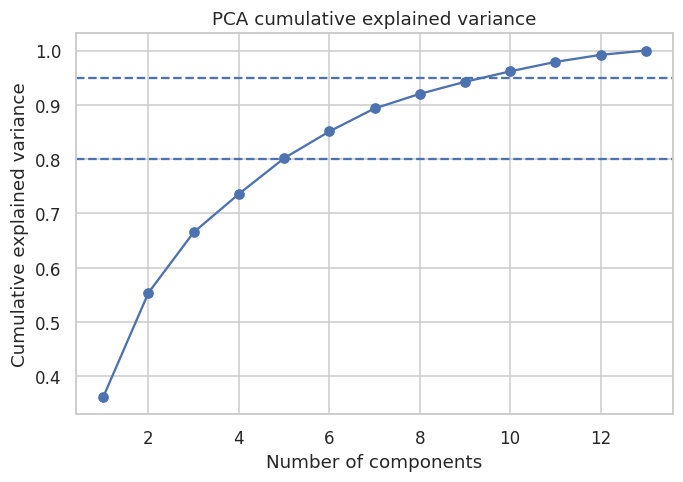

Components needed: {0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}


In [316]:
# PCA cumulative explained variance
result = components_for_variance(
    wine.drop(columns="target").values,
    standardise=True
)

plt.plot(range(1, len(result["cumulative"]) + 1),
         result["cumulative"], marker="o")

plt.axhline(0.80, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.show()

print("Components needed:", result["needed"])

**Your answer:**

(a) Without standardisation, the first principal component explains about 99.81% of the variance because proline has a much larger numerical scale than the other wine features. PCA is variance-based, so variables with larger scales dominate the components. This shows why features measured in different units should normally be standardised before PCA.

(b) After standardisation, 5 components are needed for 80% cumulative explained variance and 10 components for 95%. However, the threshold should depend on the downstream task: the number of components should be chosen based on model performance, information retention, interpretability, and computational cost rather than an arbitrary percentage alone.

(c) The statement that “component 2 is the strongest predictor” is incomplete. PCA components are combinations of the original 13 features, so component 2 is not directly one interpretable measurement. To interpret the claim, we would need the PCA loadings and evidence that component 2 actually predicts the target well in the fitted model.

## 11. Task 10 — A two-dimensional projection of 784 dimensions

Applied, and the last mechanical task. This is the projection Lesson 3
clusters.

`mnist_sample.csv` is 1500 handwritten digits, each a 28 by 28 image
flattened into 784 pixel columns. Reducing with PCA before running t-SNE
is standard practice: it removes noise and makes t-SNE several times
faster.

*see Practice 2 §15.2, §15.5 and §15.6*

In [317]:
from sklearn.manifold import TSNE

def project_two_ways(X, perplexity, seed, n_pca=50):
    """Project a high-dimensional array to 2-D, twice, and compare."""

    # 1. Standardise X
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 2. PCA reduction for the t-SNE input
    pca_reduced = PCA(
        n_components=n_pca,
        random_state=seed
    )
    reduced = pca_reduced.fit_transform(X_scaled)

    # 3. t-SNE from the PCA-reduced data
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=seed,
        init="pca"
    )
    tsne_2d = tsne.fit_transform(reduced)

    # Separate 2-component PCA for comparison
    pca_2 = PCA(
        n_components=2,
        random_state=seed
    )
    pca_2d = pca_2.fit_transform(X_scaled)

    explained_2d = float(
        pca_2.explained_variance_ratio_.sum()
    )

    return {
        "pca_2d": pca_2d,
        "tsne_2d": tsne_2d,
        "explained_2d": explained_2d,
        "reduced": reduced
    }

In [318]:
mnist = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/mnist_sample.csv"
)
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

pixels (1500, 784)  labels (1500,)
one row reshaped back into an image: (28, 28)


In [319]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
#mnist = pd.read_csv("../datasets/mnist_sample.csv")
#digit_labels = mnist["label"].values
#pixels = mnist.drop(columns="label").values

#print("pixels", pixels.shape, " labels", digit_labels.shape)
#print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
#_small = pixels[:300]
#_projection = project_two_ways(_small, perplexity=30, seed=SEED)

In [320]:
assert set(_projection) == {"pca_2d", "tsne_2d", "explained_2d", "reduced"}
assert _projection["pca_2d"].shape == (300, 2), f"pca_2d shape {_projection['pca_2d'].shape}"
assert _projection["tsne_2d"].shape == (300, 2), f"tsne_2d shape {_projection['tsne_2d'].shape}"
assert _projection["reduced"].shape == (300, 50), f"reduced shape {_projection['reduced'].shape}"
assert 0.0 < _projection["explained_2d"] < 1.0

# Two linear components cannot carry much of 784 dimensions.
assert _projection["explained_2d"] < 0.30, \
    f"two components explaining {_projection['explained_2d']:.1%} of 784 dimensions looks wrong"

# Seeded, so the same call reproduces exactly...
_again = project_two_ways(_small, perplexity=30, seed=SEED)
assert np.allclose(_projection["tsne_2d"], _again["tsne_2d"]), \
    "same seed must give the same embedding; did you pass random_state?"

# ...and a different seed does not.
_other = project_two_ways(_small, perplexity=30, seed=SEED + 1)
assert not np.allclose(_projection["tsne_2d"], _other["tsne_2d"]), \
    "a different seed should give a different embedding"

# t-SNE is not PCA: the two projections must differ.
assert not np.allclose(_projection["pca_2d"], _projection["tsne_2d"])

# t-SNE places THESE points and has no rule for placing new ones. Ask the
# class, not an instance -- there is nothing to seed and nothing to fit.
assert not hasattr(TSNE, "transform"), \
    "t-SNE has no transform, which is why it cannot be a preprocessing step"
assert hasattr(PCA, "transform"), "PCA does have one, and that is the difference"

print(f"two PCA components carry {_projection['explained_2d']:.2%} of the variance")
print("Task 10 passed.")

two PCA components carry 13.58% of the variance
Task 10 passed.


### Question 7 — perplexity, and the seed

Using the **full** 1500 rows this time, produce three t-SNE projections at
`perplexity` = 5, 30 and 50, all with the same seed, and draw them side by
side coloured by `digit_labels`. Then produce two more at `perplexity=30`
with two **different** seeds.

**(a)** Describe how the picture changes across the three perplexities.
Roughly what is perplexity controlling — say it in terms of how many
neighbours each point is trying to stay close to. Which extreme shatters
the classes and which merges them?

**(b)** Your two different-seed runs at the same perplexity also differ.
Explain why t-SNE is seed-dependent at all, and what that means for a
figure published without a stated `random_state`.

**(c)** Compare any of your t-SNE panels with the `pca_2d` projection. The
t-SNE picture separates the digits far better. State **three things you
still cannot conclude** from it — refer to Practice 2 §15.7 — and say which
of the two projections you would use as input to a clustering algorithm,
and why.

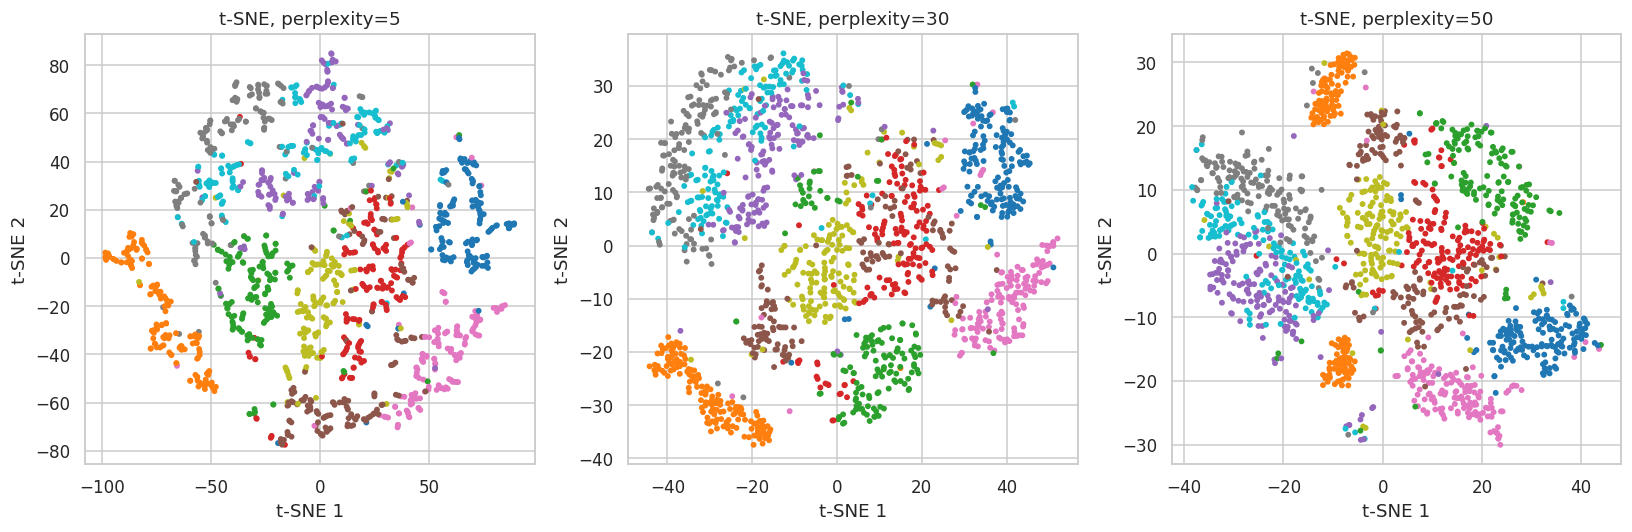

In [321]:
# Question 7 — perplexity and seed

perplexities = [5, 30, 50]
seed = SEED

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, perplexity in zip(axes, perplexities):
    result = project_two_ways(
        pixels,
        perplexity=perplexity,
        seed=seed
    )

    ax.scatter(
        result["tsne_2d"][:, 0],
        result["tsne_2d"][:, 1],
        c=digit_labels,
        cmap="tab10",
        s=8
    )

    ax.set_title(f"t-SNE, perplexity={perplexity}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

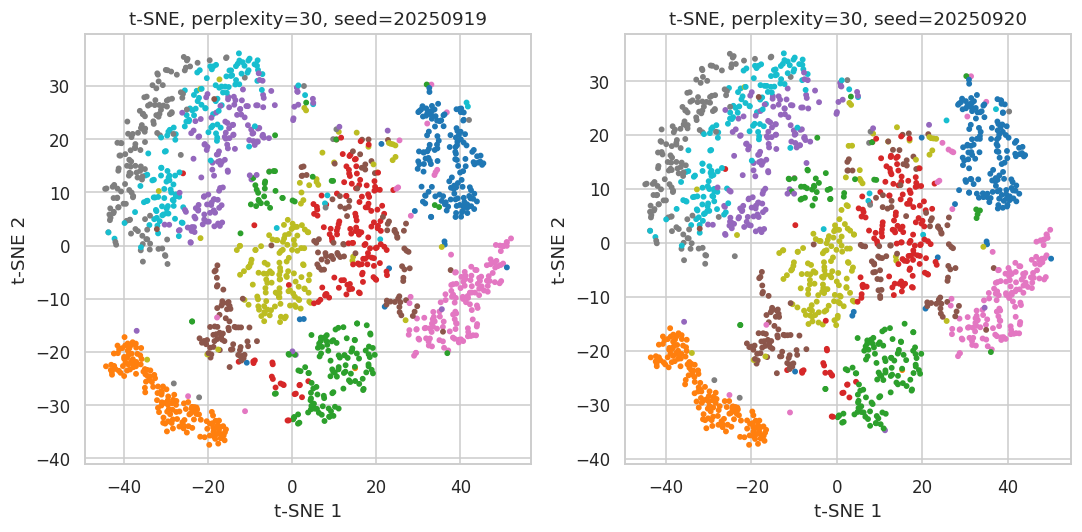

In [322]:
seeds = [SEED, SEED + 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, seed in zip(axes, seeds):
    result = project_two_ways(
        pixels,
        perplexity=30,
        seed=seed
    )

    ax.scatter(
        result["tsne_2d"][:, 0],
        result["tsne_2d"][:, 1],
        c=digit_labels,
        cmap="tab10",
        s=8
    )

    ax.set_title(f"t-SNE, perplexity=30, seed={seed}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

**Your answer:**
(a) Perplexity controls roughly how many neighbouring points t-SNE tries to preserve around each observation. In these results, perplexity 5 produces the most fragmented structure, with several digit classes split into smaller groups. At perplexity 30 the clusters become more coherent while remaining reasonably separated. At perplexity 50 the structure is smoother and more compact, but some classes overlap or merge more. Thus, lower perplexity emphasises very local structure and fragments the classes more, while higher perplexity considers a broader neighbourhood and tends to merge the structure more.

(b) With perplexity fixed at 30, changing the seed from 20250919 to 20250920 produced very similar projections in this run. However, t-SNE is seed-dependent because its optimisation is stochastic, so different random initialisation or optimisation paths can produce different 2-D layouts. Therefore, a published t-SNE figure without a stated random_state may not be exactly reproducible.

(c) Compared with the PCA 2-D projection, the t-SNE projections separate the digit classes more clearly. However, three conclusions cannot be made from this alone:
1. We cannot conclude that the apparent distances between separate t-SNE clusters represent true distances between digit classes in the original 784-dimensional space, because t-SNE primarily preserves local neighbourhood structure.
2. We cannot conclude that the visible cluster sizes, shapes, or spacing have a direct quantitative interpretation in the original feature space.
3. We cannot conclude from this plot alone that a particular clustering algorithm will recover the digit classes accurately. That would require applying and evaluating the clustering method separately against an appropriate criterion._

## 12. Task 11 — A figure that answers a stated question

Applied. The question: **does the daily demand profile for bicycles differ
between working days and non-working days, and how does weather change
it?**

*see Practice 2 §8.4, §9 and §10*

In [323]:
def demand_profile_figure(bikes_frame):
    """Draw a two-panel figure answering the question above. Return (fig, axes)."""

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # LEFT PANEL: working day vs non-working day
    working_profile = (
        bikes_frame
        .groupby(["hr", "workingday"])["cnt"]
        .mean()
        .unstack()
    )

    for workingday in working_profile.columns:
        label = "Working day" if workingday == 1 else "Non-working day"

        axes[0].plot(
            working_profile.index,
            working_profile[workingday],
            label=label
        )

    axes[0].set_xlabel("Hour")
    axes[0].set_ylabel("Mean bicycle demand")
    axes[0].set_title("Demand by hour: working vs non-working days")
    axes[0].legend()


    # RIGHT PANEL: weather situation
    weather_profile = (
        bikes_frame
        .groupby(["hr", "weathersit"])["cnt"]
        .mean()
        .unstack()
    )

    weather_labels = {
        1: "Clear",
        2: "Mist / Cloudy",
        3: "Light precipitation",
        4: "Heavy precipitation"
    }

    for weather in weather_profile.columns:
        axes[1].plot(
            weather_profile.index,
            weather_profile[weather],
            label=weather_labels.get(weather, str(weather))
        )

    axes[1].set_xlabel("Hour")
    axes[1].set_ylabel("Mean bicycle demand")
    axes[1].set_title("Demand by hour and weather")
    axes[1].legend()

    fig.suptitle("Daily bicycle demand profiles")
    fig.tight_layout()

    return fig, axes

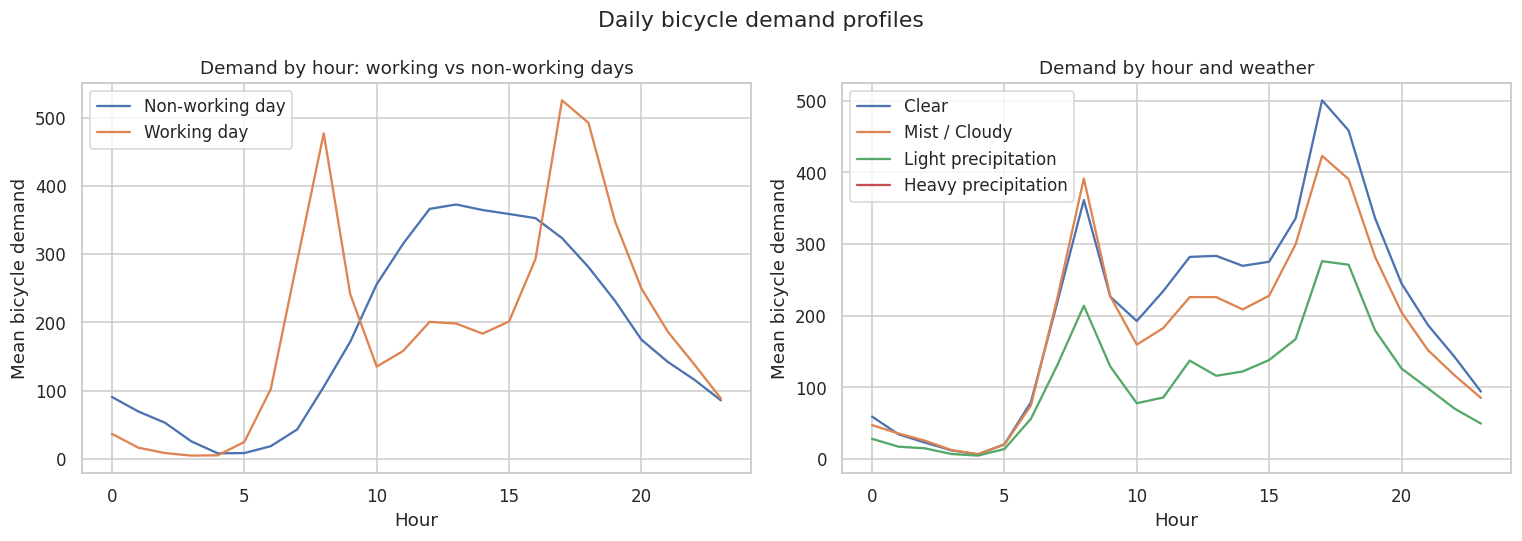

Task 11 passed.


In [324]:
_fig, _axes = demand_profile_figure(bikes)

assert len(_axes) == 2, f"expected two panels, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_legend() is not None, f"panel {_i} has no legend"
    assert len(_ax.lines) >= 2, f"panel {_i} should have at least two lines"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), "the figure has no suptitle"
assert len(_axes[0].lines) == 2, "the left panel compares exactly two groups"

plt.show()
print("Task 11 passed.")

### Question 8 — pooling and conditioning

**(a)** Draw the *pooled* profile as well: mean `cnt` by `hr` with no
conditioning. Compare it with your two-line left panel. Describe a
statement about commuter behaviour that the pooled figure would support
and that is false for both of the underlying groups.

**(b)** This is the same phenomenon as Practice 2 §12. Name it, and state
the general rule it implies about reporting an aggregate.

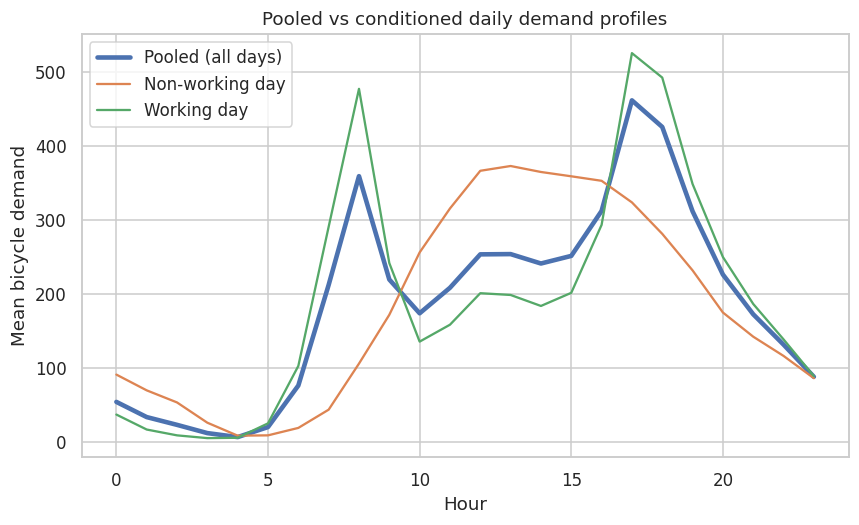

In [325]:
# Question 8 — pooled profile

pooled = bikes.groupby("hr")["cnt"].mean()

conditioned = (
    bikes.groupby(["hr", "workingday"])["cnt"]
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    pooled.index,
    pooled.values,
    label="Pooled (all days)",
    linewidth=3
)

ax.plot(
    conditioned.index,
    conditioned[0],
    label="Non-working day"
)

ax.plot(
    conditioned.index,
    conditioned[1],
    label="Working day"
)

ax.set_xlabel("Hour")
ax.set_ylabel("Mean bicycle demand")
ax.set_title("Pooled vs conditioned daily demand profiles")
ax.legend()

plt.show()

**Your answer:**

(a) The pooled profile suggests a general two-peak commuting pattern: bicycle demand rises sharply around 8:00 and again around 17:00–18:00. However, this description is false for both underlying groups. Working days show two strong commute peaks, especially around 8:00 and 17:00–18:00, whereas non-working days show a broad midday/afternoon peak rather than the same two-peak pattern. The pooled curve therefore describes neither group accurately; it mixes two different daily behaviours.

(b) This is an example of Simpson's paradox (or an aggregation effect). A relationship or pattern visible in aggregated data can change or disappear when the data are conditioned on an important grouping variable. Here, pooling working and non-working days creates an average demand profile that hides the distinct behaviour of the two groups. The general implication is that aggregate statistics can be misleading when the population contains subgroups with systematically different patterns, so relevant conditioning variables should be examined before interpreting the aggregate.

## 13. Task 12 — Open-ended

No assert. Marked on the written analysis.

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Read that table first: four of the columns are integer-coded categories,
four are physical measurements that the publisher divided by a constant,
one is a date stored as text, and `casual + registered` equals `cnt`
exactly.

**Produce a short data-quality and structure report on this table.** Cover
at least:

1. **Types.** Which columns does pandas infer wrongly, in the sense that
   the inferred type permits an operation that is meaningless? Fix them
   and show one operation that becomes an error after your fix.
2. **Units.** Restore the four normalised columns to physical units and
   sanity-check the resulting ranges against what you know about
   Washington D.C. Report anything that looks wrong.
3. **The date.** Parse `dteday`. Confirm the series is complete: is there
   one row for every hour of every day in the range? If rows are missing,
   how many, and does their absence look random?
4. **A correlation you should not compute.** Produce the correlation
   matrix of the numeric columns, then identify at least two entries in it
   that are meaningless or misleading, and say why. At least one of your
   examples must be about an integer-coded category.
5. **Leakage.** Explain why `casual` and `registered` must not be used as
   features to predict `cnt`. Then describe a realistic prediction task
   for this dataset in which using them *would* be legitimate.
6. **A recommendation.** In one paragraph: which columns would you hand to
   a model that predicts hourly demand, and which would you exclude and
   why. Practice 3 §4 fits that model, so this is a real handover.

A good answer distinguishes "wrong" from "misleading" and says which of
its findings would actually change a modelling decision.

In [326]:
# Task 12 — data quality and structure analysis

df = bikes.copy()

print("SHAPE:")
print(df.shape)

print("\nDTYPES:")
print(df.dtypes)

print("\nMISSING VALUES:")
print(df.isna().sum())

print("\nUNIQUE VALUES:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

print("\nRANGES / SUMMARY:")
print(df.describe(include="all").T)

SHAPE:
(17379, 17)

DTYPES:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

MISSING VALUES:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

UNIQUE VALUES:
instant: 17379
dteday: 731
season: 4
yr: 2
mnth: 12
hr: 24
holiday: 2
weekday: 7
workingday: 2
weathersit: 4
temp: 50
atemp: 65
hum: 89
windspeed: 30
casual: 322
registered: 776
cnt: 869

RANGES / SUMMARY:
                 count unique         top freq       mean   

In [327]:
# Date coverage and completeness

dates = pd.to_datetime(df["dteday"])

print("First date:", dates.min())
print("Last date:", dates.max())
print("Number of unique dates:", dates.nunique())
print("Number of rows:", len(df))

expected_rows = dates.nunique() * 24
missing_rows = expected_rows - len(df)

print("Expected rows if every day has 24 hours:", expected_rows)
print("Difference:", missing_rows)

# Number of recorded hours per day
hours_per_day = (
    df.assign(_date=dates)
      .groupby("_date")["hr"]
      .nunique()
)

print("\nHours per day:")
print(hours_per_day.value_counts().sort_index())

print("\nDays with fewer than 24 recorded hours:")
print(hours_per_day[hours_per_day < 24])

First date: 2011-01-01 00:00:00
Last date: 2012-12-31 00:00:00
Number of unique dates: 731
Number of rows: 17379
Expected rows if every day has 24 hours: 17544
Difference: 165

Hours per day:
hr
1       1
8       1
11      1
12      1
16      1
17      1
18      2
22      6
23     62
24    655
Name: count, dtype: int64

Days with fewer than 24 recorded hours:
_date
2011-01-02    23
2011-01-03    22
2011-01-04    23
2011-01-05    23
2011-01-06    23
              ..
2012-10-30    11
2012-11-08    23
2012-11-29    23
2012-12-24    23
2012-12-25    23
Name: hr, Length: 76, dtype: int64


In [328]:
# Sanity checks

print("season:", sorted(df["season"].unique()))
print("yr:", sorted(df["yr"].unique()))
print("mnth:", sorted(df["mnth"].unique()))
print("hr:", sorted(df["hr"].unique()))
print("holiday:", sorted(df["holiday"].unique()))
print("weekday:", sorted(df["weekday"].unique()))
print("workingday:", sorted(df["workingday"].unique()))
print("weathersit:", sorted(df["weathersit"].unique()))

print("\nNormalised measurement ranges:")
for col in ["temp", "atemp", "hum", "windspeed"]:
    print(
        col,
        "min =", df[col].min(),
        "max =", df[col].max()
    )

print("\nCount identity check:")
print("All casual + registered == cnt:",
      (df["casual"] + df["registered"] == df["cnt"]).all())

season: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
yr: [np.int64(0), np.int64(1)]
mnth: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
hr: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
holiday: [np.int64(0), np.int64(1)]
weekday: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
workingday: [np.int64(0), np.int64(1)]
weathersit: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Normalised measurement ranges:
temp min = 0.02 max = 1.0
atemp min = 0.0 max = 1.0
hum min = 0.0 max = 1.0
windspeed min = 0.0 max = 0.8507

Count identity check:
All ca

            instant  season      yr    mnth      hr  holiday  weekday  workingday  weathersit    temp   atemp     hum  \
instant      1.0000  0.4040  0.8660  0.4890 -0.0050   0.0150   0.0010     -0.0030     -0.0140  0.1360  0.1380  0.0100   
season       0.4040  1.0000 -0.0110  0.8300 -0.0060  -0.0100  -0.0020      0.0140     -0.0150  0.3120  0.3190  0.1510   
yr           0.8660 -0.0110  1.0000 -0.0100 -0.0040   0.0070  -0.0040     -0.0020     -0.0190  0.0410  0.0390 -0.0840   
mnth         0.4890  0.8300 -0.0100  1.0000 -0.0060   0.0180   0.0100     -0.0030      0.0050  0.2020  0.2080  0.1640   
hr          -0.0050 -0.0060 -0.0040 -0.0060  1.0000   0.0000  -0.0030      0.0020     -0.0200  0.1380  0.1340 -0.2760   
holiday      0.0150 -0.0100  0.0070  0.0180  0.0000   1.0000  -0.1020     -0.2520     -0.0170 -0.0270 -0.0310 -0.0110   
weekday      0.0010 -0.0020 -0.0040  0.0100 -0.0030  -0.1020   1.0000      0.0360      0.0030 -0.0020 -0.0090 -0.0370   
workingday  -0.0030  0.0140 -0.0

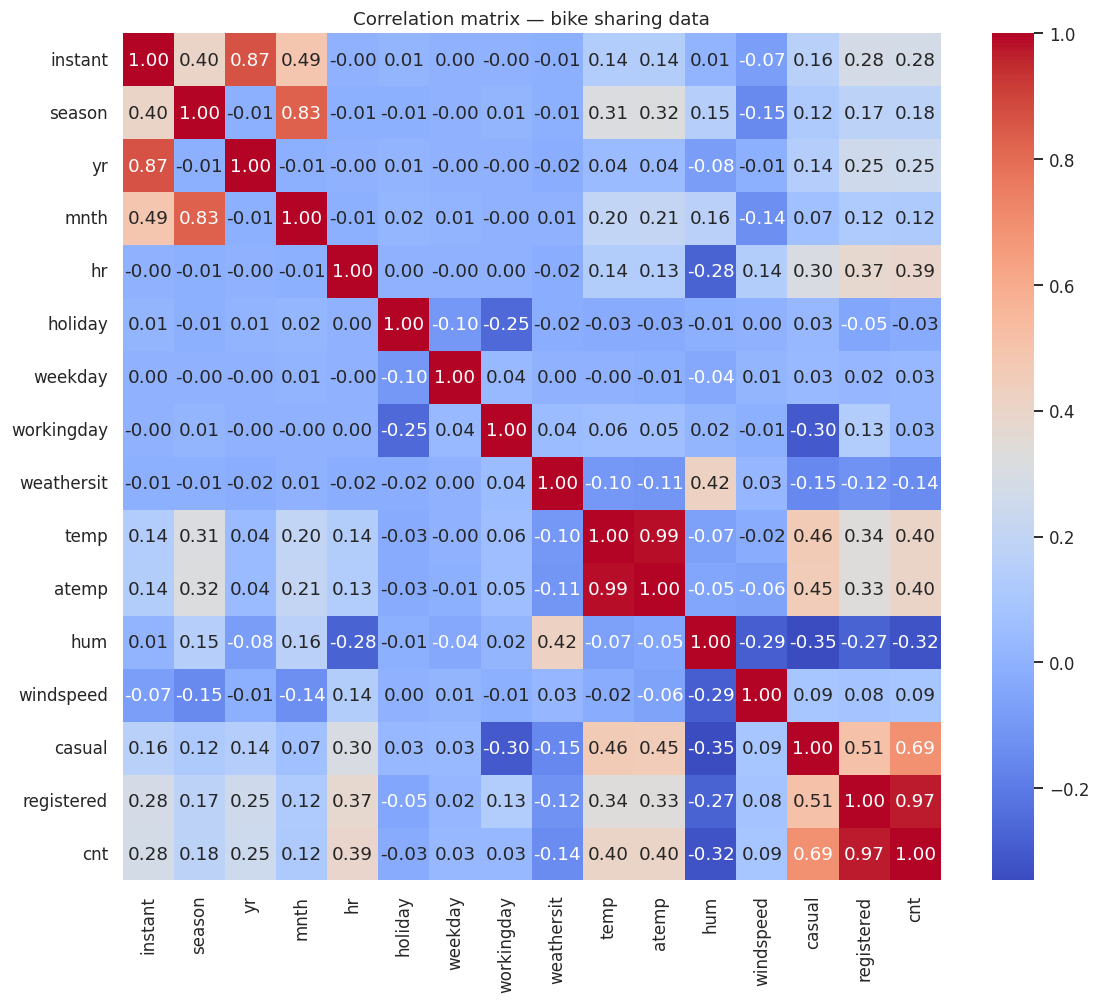

In [329]:
# Correlations between numeric columns

numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

print(corr.round(3))

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=ax
)

ax.set_title("Correlation matrix — bike sharing data")
plt.show()

In [330]:
print("Correlation with cnt:")
print(
    corr["cnt"]
    .sort_values(ascending=False)
    .round(3)
)

print("\nIdentity check:")
print(
    "casual + registered == cnt:",
    (df["casual"] + df["registered"] == df["cnt"]).all()
)

Correlation with cnt:
cnt           1.0000
registered    0.9720
casual        0.6950
temp          0.4050
atemp         0.4010
hr            0.3940
instant       0.2780
yr            0.2500
season        0.1780
mnth          0.1210
windspeed     0.0930
workingday    0.0300
weekday       0.0270
holiday      -0.0310
weathersit   -0.1420
hum          -0.3230
Name: cnt, dtype: float64

Identity check:
casual + registered == cnt: True


**Your write-up:**

1. Types
Several columns are stored as integers even though they represent categories rather than continuous numeric quantities. These include season, yr, mnth, holiday, weekday, workingday, and weathersit. Treating them as ordinary numbers would allow meaningless arithmetic operations, such as averaging weather categories. These columns should therefore be converted to categorical variables. The dteday column is stored as object and should be converted to datetime.

2. Units
The physical measurements are normalised rather than expressed directly in physical units. In this dataset, temp ranges from 0.02 to 1.00, atemp from 0.00 to 1.00, hum from 0.00 to 1.00, and windspeed from 0.00 to 0.8507. These ranges are consistent with scaled variables rather than raw temperature, humidity, or wind-speed measurements. No obvious impossible values appear in these ranges, although interpretation in physical units requires the scaling constants documented with the dataset.

3. Date completeness
The data cover 731 unique dates from 2011-01-01 through 2012-12-31. A complete hourly dataset would contain 731 × 24 = 17,544 rows, but the table contains 17,379 rows, so 165 hourly observations are absent. There are 655 days with all 24 hours recorded and 76 days with fewer than 24 recorded hours. The missingness is therefore not completely uniform across dates and should be considered when constructing time-based features or evaluating a forecasting model.

4. Correlation
The correlatSeason and month have high correlation because months determine seasons, but Pearson correlation is not fully meaningful for categorical encoded variables because numbers are only labels, not continuous quantities. Similarly, correlations involving integer-coded categorical variables such as weathersit, weekday, and workingday should not be interpreted as standard numeric relationships. Temp and atemp have a correlation of about 0.99, which is meaningful because both measure closely related temperature concepts. The target cnt is strongly correlated with registered (about 0.972) and casual (about 0.695), but these correlations should not be used to justify including those variables as predictors.

5. Leakage
casual and registered must not be used as predictors of cnt because cnt is exactly their sum: casual + registered = cnt for every row in the dataset. The identity check confirms this for all observations. Including either component, especially both, would leak direct information about the target and would produce an unrealistically easy prediction problem. These variables are legitimate only for a different task in which the corresponding quantity is actually available at prediction time.

6. Recommendation
For a model predicting future hourly bicycle demand, I would use calendar/time information such as hour, month, year, weekday, holiday and working-day status, together with weather-related variables such as temperature, apparent temperature, humidity, windspeed and weather situation, provided that they are known or forecast at prediction time. Integer-coded categorical variables should be treated as categorical features (for example with one-hot encoding or suitable categorical handling), not as continuous numeric measurements. I would exclude instant because it is only a row identifier, dteday in its raw form after extracting useful calendar features, and casual and registered because they directly compose the target and cause leakage. I would also consider avoiding simultaneous use of both temp and atemp because their correlation is approximately 0.99 and they contain highly redundant information.

## 14. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced.
- Task 12 has a written report, not only code.